# Ternary Hex Plot Pipeline for Inflection‑Based Driver Importance Analysis



### Description:  
This Python script processes multi‑year ADCIRC+SWAN hindcast outputs to extract monthly maximum water levels, sea ice concentrations, atmospheric pressure, and wind speed at shallow coastal nodes. It then detects change‑points in each node’s time series, computes normalized Pearson‑correlation “importances” for each forcing before and after inflection, and visualizes the relative contributions via side‑by‑side ternary hexagon heatmaps.


### Initialize Libraries

In [ ]:
import warnings;        import os
import pathlib as pl;   import numpy as np
import pandas as pd;    import xarray as xr
import ruptures as rpt; import matplotlib.pyplot as plt
import ternary
from dask.distributed import Client, LocalCluster
from dask.diagnostics import ProgressBar
from scipy.stats import pearsonr
from matplotlib.cm import ScalarMappable, get_cmap
from matplotlib.colors import BoundaryNorm
warnings.filterwarnings("ignore")

In [2]:
# ----------------- Initialize Functions ----------------- #
def compute_keep_idx2(
    sample_path,
    min_depth,
    max_depth,
    bbox=None,
):
    """
    Return indices of nodes whose depth is between min_depth and max_depth,
    optionally also lying within a bounding box in x/y.
    """
    ds0 = xr.open_dataset(sample_path, engine="netcdf4", mask_and_scale=False)
    
    # 1) depth mask
    depth = ds0.depth.values
    fv    = ds0.depth.encoding.get("_FillValue", None)
    mask  = np.ones_like(depth, dtype=bool)
    if fv is not None:
        mask &= (depth != fv)
    mask &= (depth >= min_depth)
    mask &= (depth <= max_depth)

    # 2) optional bbox mask
    if bbox is not None:
        min_x, max_x, min_y, max_y = bbox
        x = ds0.x.values
        y = ds0.y.values
        mask &= (x >= min_x) & (x <= max_x)
        mask &= (y >= min_y) & (y <= max_y)

    ds0.close()
    return np.where(mask)[0]


def preprocess(ds):
    """Subset to one calendar-year, drop spin‑up, and shallow nodes."""
    # decode time → pandas datetime
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    # drop spin‑up & restrict to that year
    year = ds.time.dt.year.values[600]
    mask = ds.time.dt.year == year
    ds   = ds.isel(time=mask)
    # subset to shallow nodes
    ds   = ds.isel(node=keep_idx)
    return ds


def preprocess2(ds):
    """Like preprocess, but also drop x/y to allow concatenation."""
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    year = ds.time.dt.year.values[600]
    mask = ds.time.dt.year == year
    ds   = ds.isel(time=mask)
    ds   = ds.isel(node=keep_idx)
    return ds.drop_vars(['x','y'], errors='ignore')


def detect_cp_monthly(y, times, n_bkps=1):
    """Find the first change‑point in a 1D array via ruptures."""
    idx = np.where(~np.isnan(y))[0]
    if idx.size < 6:
        return np.datetime64("NaT")
    arr = y[idx].astype(float)
    try:
        algo = rpt.Binseg(model="rbf").fit(arr.reshape(-1,1))
        bkps = algo.predict(n_bkps=n_bkps)
        cp   = bkps[0]
    except Exception:
        return np.datetime64("NaT")
    if 0 < cp < len(arr):
        return times[idx[cp]]
    return np.datetime64("NaT")

In [3]:
# ---- User Parameters ---- #
lat1, lat2 = 56, 75
lon1, lon2 = -168.5, -140
root       = '/scratch/tmiesse/project/data4spatial'
YEARS      = range(1980, 2025)
MIN_DEPTH  = 0.5
MAX_DEPTH  = 2
bbox       = (lon1, lon2, lat1, lat2)

In [4]:
# compute shallow/subset node indices once
sample_path = f"{root}/2023/fort.63.cf.nc"
keep_idx    = compute_keep_idx2(
    sample_path=sample_path,
    min_depth=MIN_DEPTH,
    max_depth=MAX_DEPTH,
    bbox=bbox
)
print(f"Keeping {len(keep_idx)} nodes")

Keeping 77189 nodes


In [5]:
# ─── Spin up Dask cluster ──────────────────────────────────────────────────────
n_workers   = int(os.environ.get("SLURM_NTASKS", "45"))
mem_per_cpu = os.environ.get("SLURM_MEM_PER_CPU", "72GB")
cluster     = LocalCluster(
    n_workers=n_workers,
    threads_per_worker=1,
    processes=True,
    memory_limit=mem_per_cpu
)
client = Client(cluster)
print(client)

<Client: 'tcp://127.0.0.1:37523' processes=45 threads=45, memory=2.95 TiB>


In [6]:
# ─── Load & preprocess datasets ────────────────────────────────────────────────
# 1) Water surface elevation
paths = [str(pl.Path(root)/str(y)/"fort.63.cf.nc") for y in YEARS]
ds_all = xr.open_mfdataset(
    paths,
    engine="h5netcdf",
    mask_and_scale=True,
    decode_cf=True,
    preprocess=preprocess,
    combine="nested",
    concat_dim="time",
    data_vars=['zeta'],
    chunks={'time': 24},
    coords="minimal"
)
times = ds_all.time.values
z     = ds_all.zeta.values
x_all = ds_all.x.values
y_all = ds_all.y.values
ds_all.close()

# 2) Sea‐ice
paths = [str(pl.Path(root)/str(y)/"fort.93.cf.nc") for y in YEARS]
ds_all = xr.open_mfdataset(
    paths, engine="h5netcdf", mask_and_scale=True,
    decode_cf=True, preprocess=preprocess,
    combine="nested", concat_dim="time",
    chunks={'time': 24}
)
ice      = ds_all.iceaf.values
time_ice = ds_all.time.values
ds_all.close()

# 3) Pressure
paths = [str(pl.Path(root)/str(y)/"fort.73.cf.nc") for y in YEARS]
ds_all = xr.open_mfdataset(
    paths, engine="h5netcdf", mask_and_scale=True,
    decode_cf=True, preprocess=preprocess,
    combine="nested", concat_dim="time",
    chunks={'time': 24}
)
press      = ds_all.pressure.values
time_press = ds_all.time.values
ds_all.close()

# 4) Wind components → speed
paths = [str(pl.Path(root)/str(y)/"fort.74.cf.nc") for y in YEARS]
ds_all = xr.open_mfdataset(
    paths, engine="h5netcdf", mask_and_scale=True,
    decode_cf=True, preprocess=preprocess2,
    combine="nested", concat_dim="time",
    chunks={'time': 24}
)
with ProgressBar():
    wind_speed = (xr.ufuncs.sqrt(ds_all['windx']**2 + ds_all['windy']**2)
                  .rename('wind_speed')
                  .persist())
time_wind = ds_all.time.values
ds_all.close()

In [7]:
# ─── Build monthly‐max dataset ─────────────────────────────────────────────────
da_zeta_mon  = xr.DataArray(z,     dims=('time','node'),
                    coords={'time': times, 'node': keep_idx},
                    name='zeta').resample(time='M').max()
da_ice_mon   = xr.DataArray(ice,   dims=('time','node'),
                    coords={'time': time_ice, 'node': keep_idx},
                    name='sea_ice').resample(time='M').max()
da_press_mon = xr.DataArray(press, dims=('time','node'),
                    coords={'time': time_press, 'node': keep_idx},
                    name='pressure').resample(time='M').min()
da_wind_mon  = wind_speed.resample(time='M').max()

ds_monthly = xr.merge([
    da_zeta_mon.to_dataset(),
    da_ice_mon.to_dataset(),
    da_press_mon.to_dataset(),
    da_wind_mon.to_dataset()
])
out_nc = '/scratch/tmiesse/project/monthly_max.nc'
ds_monthly.to_netcdf(out_nc, format='NETCDF4', engine='h5netcdf')
ds_monthly = xr.open_dataset(out_nc, engine='h5netcdf', mask_and_scale=True)

In [8]:
# ─── Detect inflection points per node ─────────────────────────────────────────
times = ds_monthly.time.values
zeta  = ds_monthly.zeta

da_inf = xr.apply_ufunc(
    detect_cp_monthly, zeta,
    input_core_dims=[['time']],
    output_core_dims=[[]],
    vectorize=True, kwargs={'times': times},
    dask='parallelized',
    output_dtypes=['datetime64[ns]']
).rename('inflection_date')

da_inf = da_inf.assign_coords({
    'node': keep_idx,
    'x': ('node', x_all),
    'y': ('node', y_all),
})
ds_inf_mon = da_inf.to_dataset()
inf_nc    = '/scratch/tmiesse/project/inflection_monthly_150k.nc'
ds_inf_mon.to_netcdf(inf_nc, format='NETCDF4', engine='h5netcdf')
ds_inf_mon = xr.open_dataset(inf_nc, engine='h5netcdf')

In [9]:
# ─── Compute pre/post‐inflection importances ─────────────────────────────────
nnode     = ds_inf_mon.dims['node']
inf_dates = ds_inf_mon.inflection_date.values

# prepare arrays
pre_frac_ice  = np.full(nnode, np.nan)
pre_frac_wind = np.full(nnode, np.nan)
pre_frac_pres = np.full(nnode, np.nan)
post_frac_ice  = np.full(nnode, np.nan)
post_frac_wind = np.full(nnode, np.nan)
post_frac_pres = np.full(nnode, np.nan)

zeta_arr = ds_monthly.zeta.values
ice_arr  = ds_monthly.sea_ice.values
wind_arr = ds_monthly.wind_speed.values
pres_arr = ds_monthly.pressure.values
times    = ds_monthly.time.values

for i in range(nnode):
    cut = inf_dates[i]
    if np.isnat(cut):
        continue

    pre_mask  = times <  cut
    post_mask = times >= cut

    def compute_importance(mask):
        if mask.sum() < 4:
            return (np.nan, np.nan, np.nan)
        rs = []
        for arr in (ice_arr, wind_arr, pres_arr):
            x = zeta_arr[mask, i]
            y = arr[mask, i]
            valid = np.isfinite(x) & np.isfinite(y)
            rs.append(abs(pearsonr(x[valid], y[valid])[0]) if valid.sum() >= 4 else 0.0)
        total = sum(rs)
        return tuple(r/total for r in rs) if total > 0 else (0.0, 0.0, 0.0)

    pre_frac_ice[i],  pre_frac_wind[i],  pre_frac_pres[i]  = compute_importance(pre_mask)
    post_frac_ice[i], post_frac_wind[i], post_frac_pres[i] = compute_importance(post_mask)

ds_imp = xr.Dataset({
    'pre_frac_ice':  (('node',), pre_frac_ice),
    'pre_frac_wind': (('node',), pre_frac_wind),
    'pre_frac_pres': (('node',), pre_frac_pres),
    'post_frac_ice':  (('node',), post_frac_ice),
    'post_frac_wind': (('node',), post_frac_wind),
    'post_frac_pres': (('node',), post_frac_pres),
}, coords={
    'node': keep_idx,
    'x':     ('node', x_all),
    'y':     ('node', y_all),
    'inflection_date': ('node', inf_dates)
})

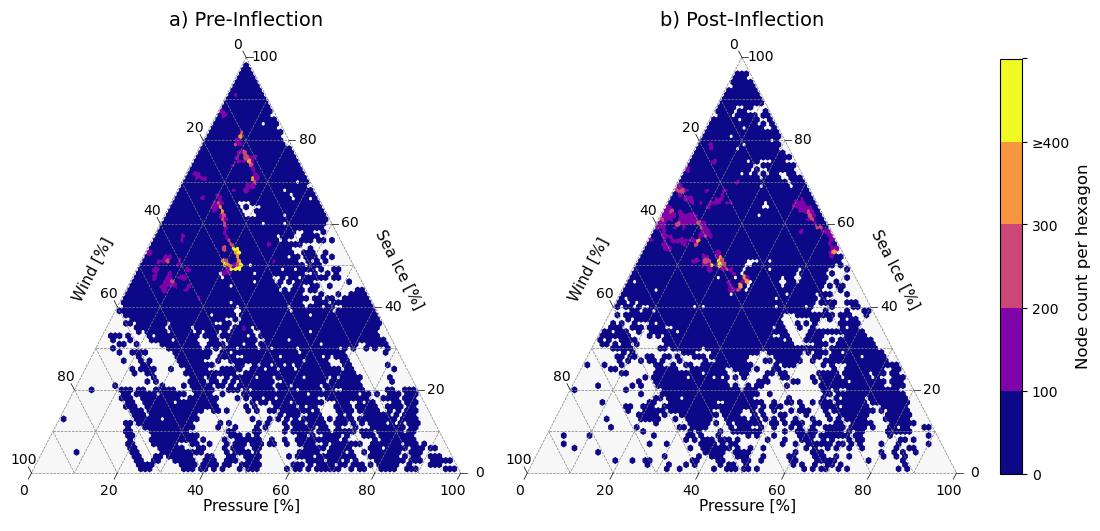

In [10]:
# ─── Ternary hex plot of importances ───────────────────────────────────────────
# stack pre/post arrays
frac_pre_raw  = np.vstack([ds_imp.pre_frac_ice .values,
                           ds_imp.pre_frac_wind.values,
                           ds_imp.pre_frac_pres.values])
frac_post_raw = np.vstack([ds_imp.post_frac_ice .values,
                           ds_imp.post_frac_wind.values,
                           ds_imp.post_frac_pres.values])

mask_pre  = np.all(np.isfinite(frac_pre_raw),  axis=0)
mask_post = np.all(np.isfinite(frac_post_raw), axis=0)

frac_pre  = frac_pre_raw[:,  mask_pre]
frac_post = frac_post_raw[:, mask_post]

# bin counts
from collections import Counter
def make_counts(frac, res=100):
    cnt = Counter()
    for l1, l2, _ in zip(*frac):
        i = int(np.floor(l1 * res))
        j = int(np.floor(l2 * res))
        k = res - i - j
        cnt[(i, j, k)] += 1
    return cnt

counts_pre  = make_counts(frac_pre)
counts_post = make_counts(frac_post)

# discrete colormap
all_vals = np.array(list(counts_pre.values()) + list(counts_post.values()))
n_bins   = 5
cmap     = get_cmap('plasma', n_bins)
bins     = np.linspace(0, 500, n_bins+1)
norm     = BoundaryNorm(bins, ncolors=cmap.N)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), facecolor='white')
fig.subplots_adjust(left=0.02, right=0.90, top=0.98, bottom=0.02, wspace=0.05)

for ax, counts, title in zip(
    (ax1, ax2),
    (counts_pre, counts_post),
    ("a) Pre‑Inflection", "b) Post‑Inflection"),
):
    # filter zeros on edges
    counts = {k: v for k, v in counts.items() if not (0 in k or k[2] == 100)}
    _, tax = ternary.figure(scale=100, ax=ax)
    tax.ax.axis('off')
    tax.boundary(linewidth=0)
    tax.gridlines(multiple=10, color="gray", linestyle="--")
    tax.ticks(axis='lbr', multiple=20, linewidth=0.5, tick_formats="%.0f", offset=0.015)
    tax.left_axis_label("Wind [%]",        offset=0.115, rotation=60,  fontsize=11)
    tax.right_axis_label("Sea Ice [%]",    offset=0.115, rotation=-60, fontsize=11)
    tax.bottom_axis_label("Pressure [%]",  offset=-0.05, fontsize=11)
    tax.set_title(title, pad=12, fontsize=14)
    tax.heatmap(counts, style='hexagonal', cmap=cmap, vmin=bins[0], vmax=bins[-1], colorbar=False)

# shared colorbar
sm   = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(all_vals)
cax  = fig.add_axes([0.92, 0.115, 0.02, 0.83])
cbar = plt.colorbar(sm, cax=cax, boundaries=bins, ticks=bins, spacing='proportional')
labels = [f"{int(b)}" for b in bins]
labels[-2] = "≥400"
labels[-1] = " "
cbar.set_ticklabels(labels)
cbar.set_label('Node count per hexagon', fontsize=12)

plt.savefig(
    '/scratch/tmiesse/project/figures/ternary_hex_w_filter_v3.png',
    dpi=300, bbox_inches='tight'
)
plt.show()